In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## New Plots

In [5]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 250_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

In [6]:
number_concepts = [2]
environments = ["cyclic_4","tree_7"]

random_results_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
random_selection_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_selection_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
multiple_selection_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
lp_selection_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
basic_comparison_baseline = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]

for i,n in enumerate(number_concepts):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False, 'run_imperfect': False, 'run_intervention': False})
        
        if len(matching_params) == 0 or 'basic_comparison' not in matching_params[0] or 'random' not in matching_params[0]['basic_comparison']:
            res = [0,0,0,0,0]
            all_vals = [res]
        else:
            print(e,n,len(matching_params))
            all_vals = []
            for m in matching_params:
                if 'multiple' in m['basic_comparison']:
                    res = [
                        m['basic_comparison']['random']['reward'],
                        m['basic_comparison']['random_selection']['reward'],
                        m['basic_comparison']['greedy']['reward'],
                        m['basic_comparison']['multiple']['reward'],
                        m['basic_comparison']['lp']['reward'],
                    ]
                else:
                    res = [
                        m['basic_comparison']['random']['reward'],
                        m['basic_comparison']['random_selection']['reward'],
                        m['basic_comparison']['greedy']['reward'],
                        m['basic_comparison']['greedy_iterative']['reward'],
                        m['basic_comparison']['lp']['reward'],
                    ]
                all_vals.append(res)
        random_results_baseline[j][i] = [i[0] for i in all_vals]
        random_selection_baseline[j][i] = [i[1] for i in all_vals]
        greedy_selection_baseline[j][i] = [i[2] for i in all_vals]
        multiple_selection_baseline[j][i] = [i[3] for i in all_vals]
        lp_selection_baseline[j][i] = [i[4] for i in all_vals]
        basic_comparison_baseline[j][i] = [m['ground_truth']['reward'] for m in matching_params]


cyclic_4 2 1
tree_7 2 1


In [7]:
fixed_accuracies = [[0.5,0.75,0.9],[0.5,0.75,0.9]]

num_concepts_selected = [2,2]
num_concepts = [3,4]
environments = ["cyclic_4","tree_7"]

greedy_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
for j,e in enumerate(environments):
    for i,n in enumerate(fixed_accuracies[j]):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': False,
                        'cbm_accuracy_by_concept': [n for i in range(num_concepts[j])]})
        print(e,len(matching_params))
        assert len(matching_params) <= 3
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0] and 'multiple_lp' in matching_params[0]['inaccurate_comparison']:
            imperfect_comparison = matching_params[0]['inaccurate_comparison']
            res = [
                [i['inaccurate_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

    greedy_selection[j].append(greedy_selection_baseline[j][0])
    lp_selection[j].append(lp_selection_baseline[j][0])
    imperfect_selection[j].append(multiple_selection_baseline[j][0])
    multiple_selection[j].append(multiple_selection_baseline[j][0])
lp_selection = lp_selection[-1]

cyclic_4 3
cyclic_4 3
cyclic_4 3
tree_7 3
tree_7 3
tree_7 3


In [8]:
synthetic_example = json.load(open("../../results/synthetic/optimal.json"))

4 six_color 1


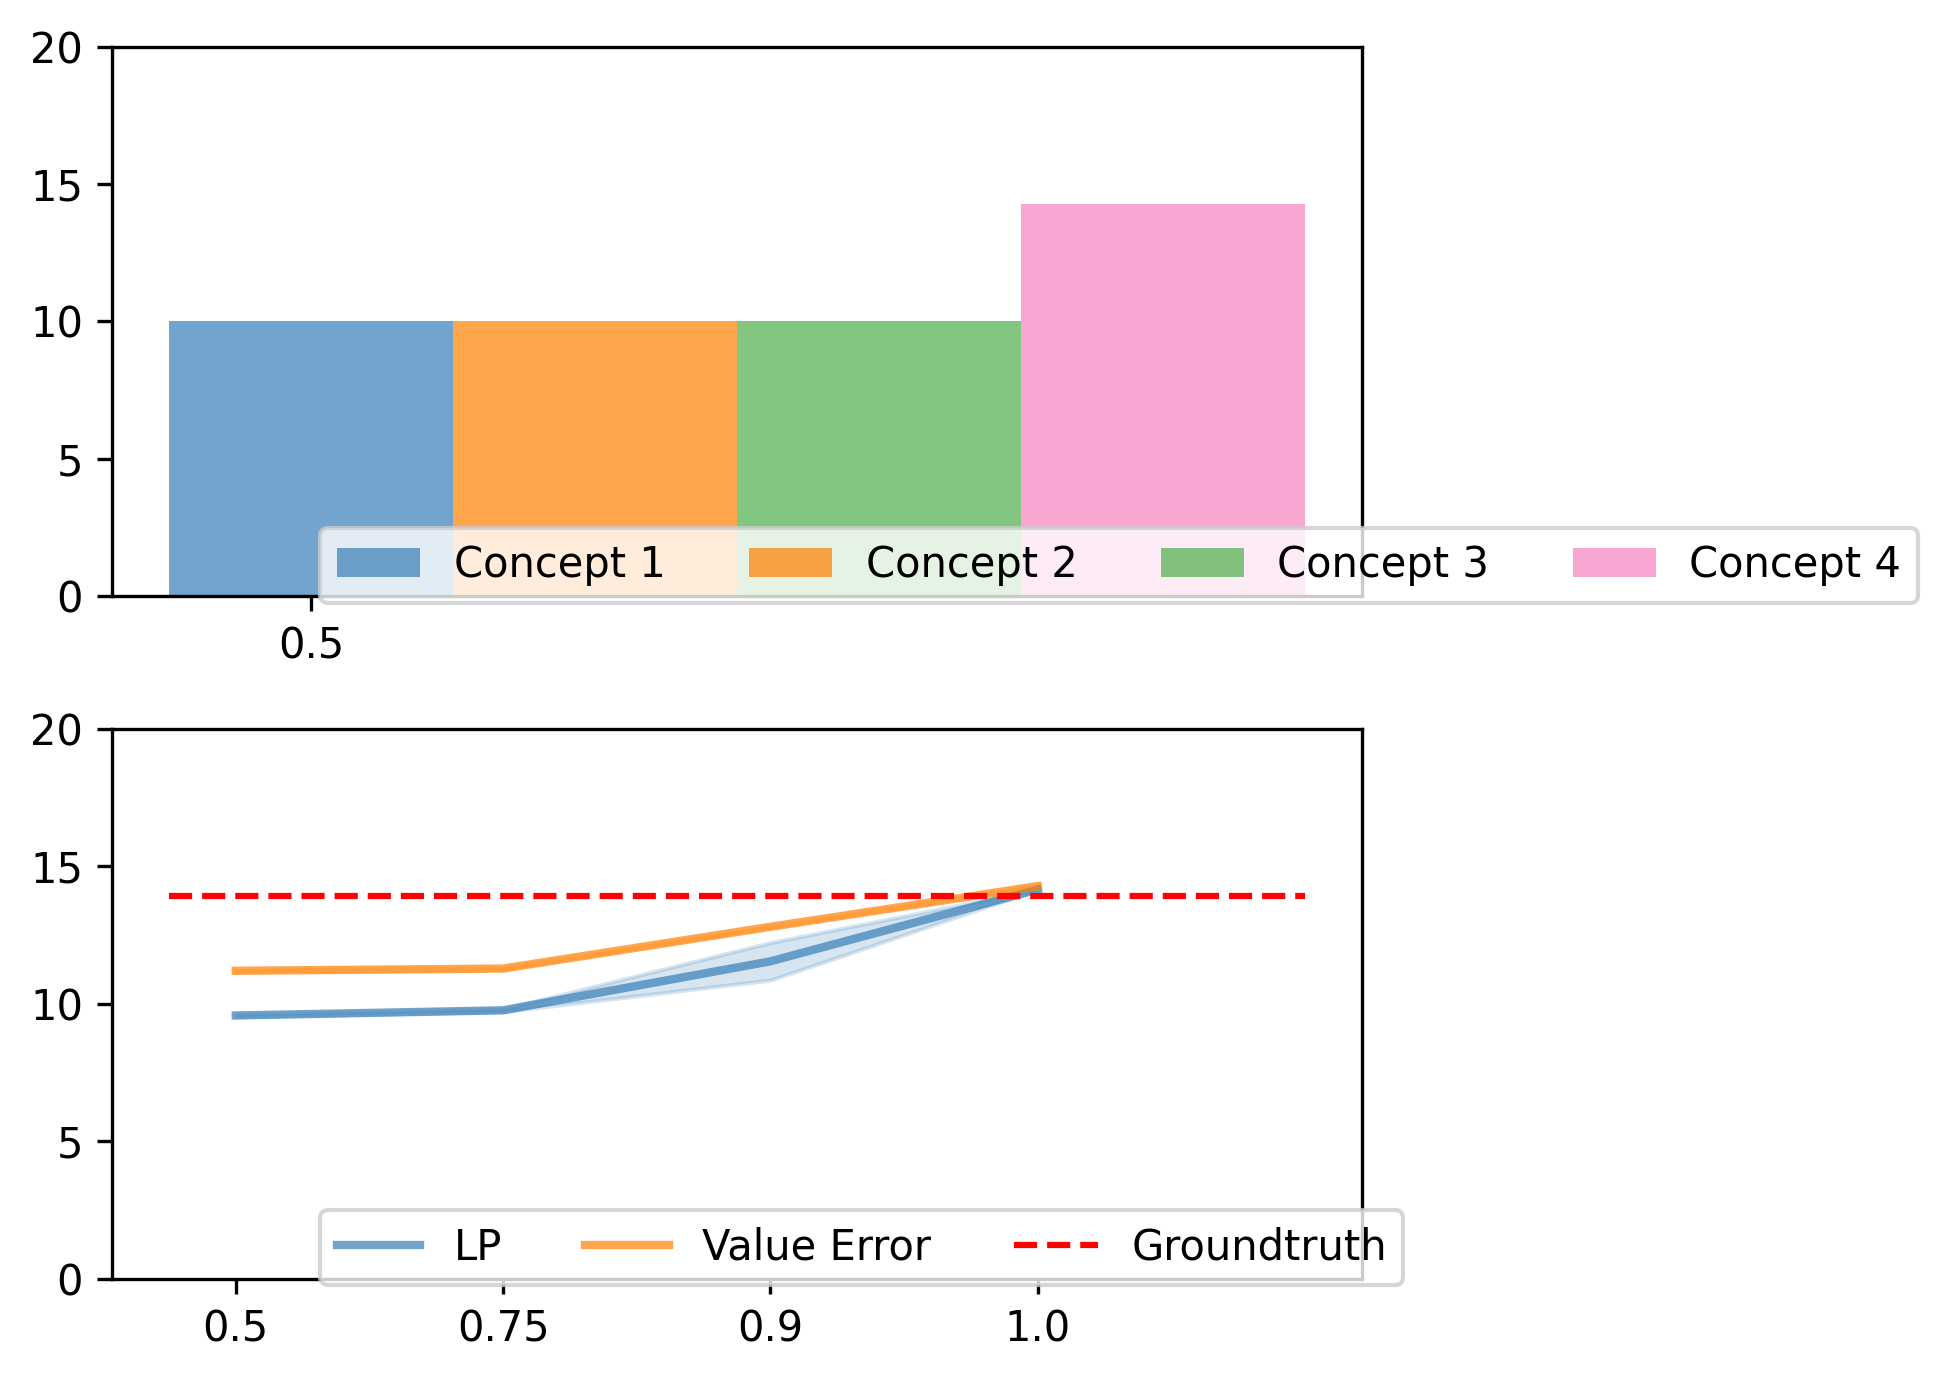

In [9]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (2,1)


titles = [["","","Cyclic"],["","","Tree"]]

sup_y_label = ""
overall_format = {'figsize':(5,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,20] for i in range(1)] for j in range(2)],
    'x_ticks': [[[list(range(4)),[0.5,0.75,0.9,1.0]] for i in range(1)] for j in range(2)],
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Value Error"]

x_groups = [list(range(len(arr))) for arr in [lp_selection,synthetic_example['val_by_accuracy']]]
y_vals = [[np.mean(arr[j]) for j in range(len(arr))] for arr in [lp_selection]]
y_vals += [synthetic_example['val_by_accuracy']]
y_std = [[np.std(arr[j])/len(arr[j])**.5 for j in range(len(arr))] for arr in [lp_selection]]
y_std += [[0 for i in range(len(synthetic_example['val_by_accuracy']))]]
plot_line(ax[1][0],x_groups,y_vals,y_std,all_labels,line_format)
scatter_format = {'color_palette': 'six_color', 'linewidth': 2,'size': 50}
ax[1][0].hlines(np.mean(basic_comparison_baseline[1][0]),-0.25,len(x_groups[0]),label="Groundtruth",color="red",linestyle="--")
bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
plot_bar(ax[0][0],list(range(len(synthetic_example['val_by_concept']))),synthetic_example['val_by_concept'],[0 for i in range(len(synthetic_example['val_by_concept']))], {0: 'Concept 1', 1: 'Concept 2', 2: 'Concept 3', 3: 'Concept 4'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/synthetic_experiments.pdf",dpi=300, bbox_inches='tight')


In [10]:
two_stage = []
basic_comparison = []
environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 0
}

all_performances = []
all_baselines = []

for j,e in enumerate(environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[environments[j]],
                                                                  'num_concepts_selected': num_concepts_selected[e]})
    print(len(matching_params))
    if len(matching_params) > 0:
        performance = [matching_params[0][i]['reward'] for i in ['random','entropy','greedy','lp','multiple']]
        baselines = [matching_params[0][i]['reward'] for i in ['ground_truth','perfect_concepts', 'imperfect_concepts']]
    else:
        performance = [0 for i in ['random','entropy','greedy','lp','multiple']]
        baselines = [0 for i in ['ground_truth','perfect_concepts', 'imperfect_concepts']]
    all_performances.append(performance)
    all_baselines.append(baselines)


1
1
1
1
0


5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


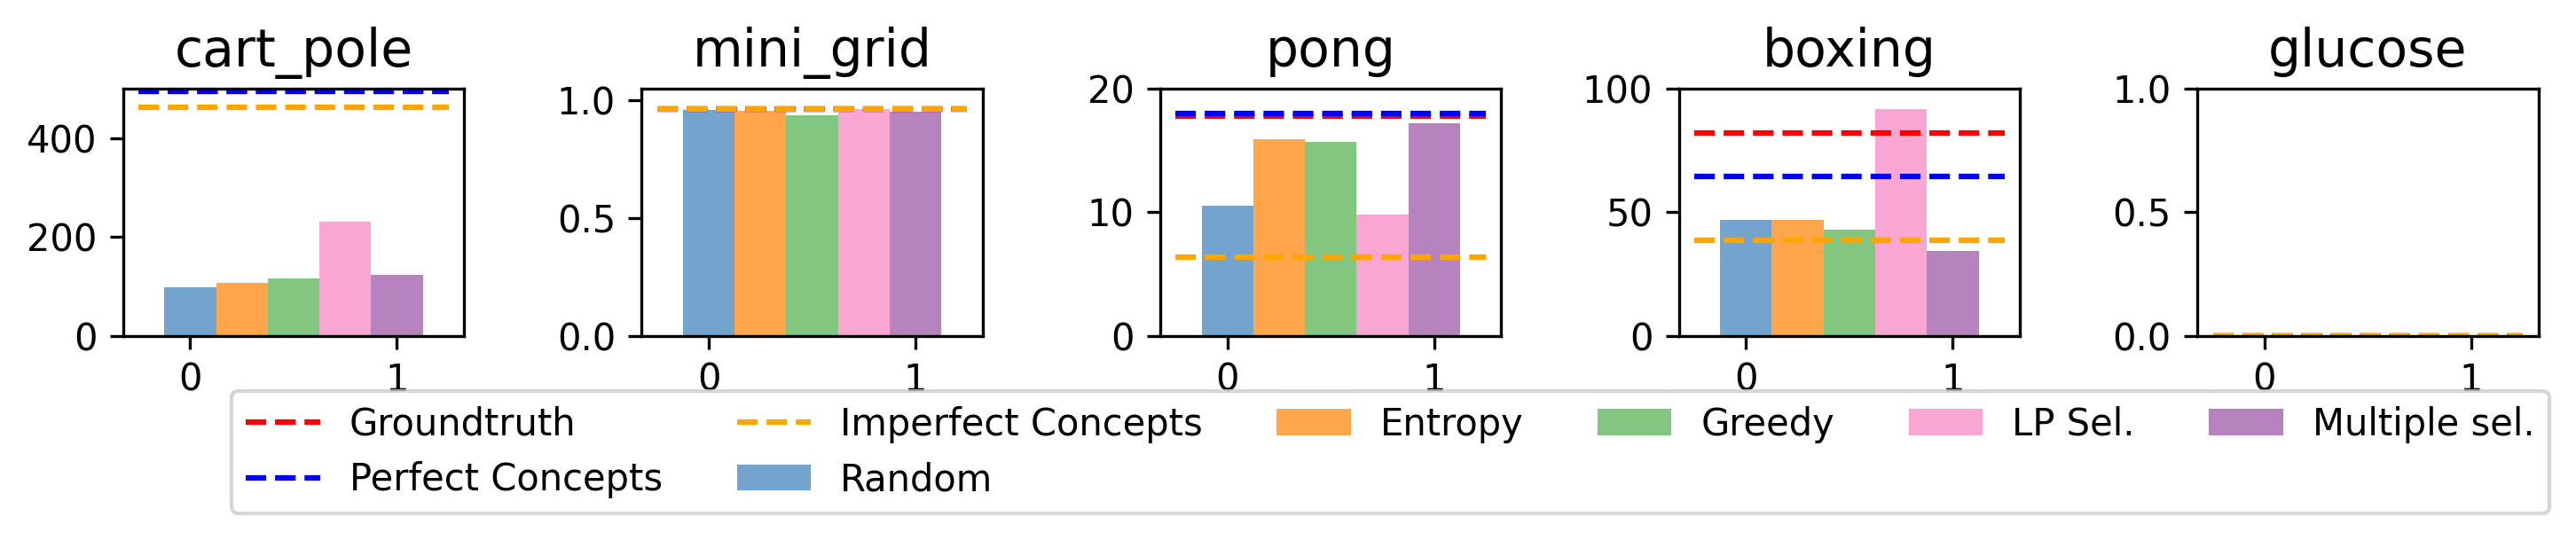

In [11]:
environments = ["cart_pole","mini_grid","pong","boxing","glucose"]
plot_dimensions = (1,len(environments))

titles = [environments]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,500],[0,1.05],[0,20],[0,100],[0,1]]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(environments)):
    x_groups = list(range(len(all_performances[i])))
    y_vals = all_performances[i]

    d = {
        0: 'Random',
        1: 'Entropy',
        2: 'Greedy',
        3: 'LP Sel.',
        4: 'Multiple sel.'
    }

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)

    colors = ["red","blue","orange"]

    for c,v,label in zip(colors,all_baselines[i],["Groundtruth","Perfect Concepts","Imperfect Concepts"]):
        ax[0][i].hlines(v,-0.25,1.25,label=label,color=c,linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods.pdf",dpi=300, bbox_inches='tight')

In [12]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[1,2,3]]
accuracies = [0.75,0.85,0.975]
max_perf = [i[1]+0.001 for i in all_baselines]

heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(environments))]

for i,e in enumerate(environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params))

            if len(matching_params) > 0:
                heatmap_by_env[i][j][k] = np.mean([m['lp']['reward'] for m in matching_params])/max_perf[i]


cart_pole 0.75 1 1
cart_pole 0.75 2 1
cart_pole 0.75 3 1
cart_pole 0.85 1 1
cart_pole 0.85 2 1
cart_pole 0.85 3 1
cart_pole 0.975 1 1
cart_pole 0.975 2 1
cart_pole 0.975 3 1
mini_grid 0.75 3 1
mini_grid 0.75 6 1
mini_grid 0.75 11 1
mini_grid 0.85 3 1
mini_grid 0.85 6 1
mini_grid 0.85 11 1
mini_grid 0.975 3 1
mini_grid 0.975 6 1
mini_grid 0.975 11 1
pong 0.75 14 1
pong 0.75 28 1
pong 0.75 57 1
pong 0.85 14 1
pong 0.85 28 0
pong 0.85 57 0
pong 0.975 14 0
pong 0.975 28 0
pong 0.975 57 0
boxing 0.75 12 1
boxing 0.75 24 1
boxing 0.75 48 1
boxing 0.85 12 1
boxing 0.85 24 1
boxing 0.85 48 0
boxing 0.975 12 0
boxing 0.975 24 0
boxing 0.975 48 0
glucose 0.75 1 0
glucose 0.75 2 0
glucose 0.75 3 0
glucose 0.85 1 0
glucose 0.85 2 0
glucose 0.85 3 0
glucose 0.975 1 0
glucose 0.975 2 0
glucose 0.975 3 0


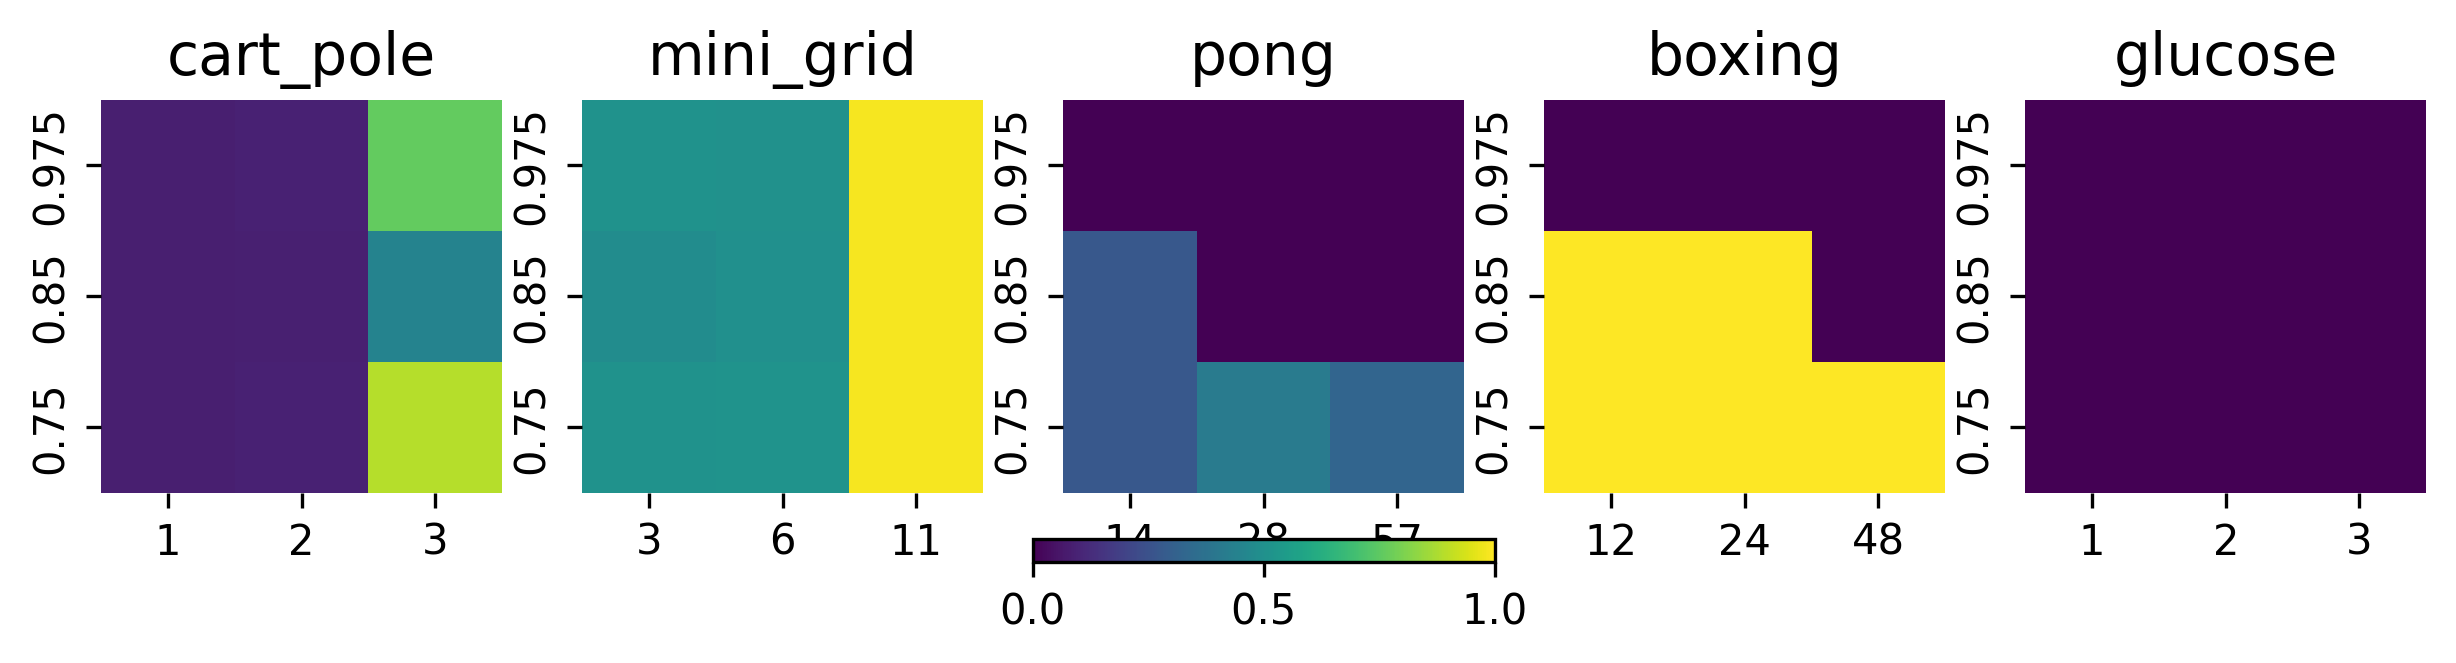

In [13]:
plot_dimensions = (1,len(environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(environments)):
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=accuracies,
        vmin=0, vmax=1,   # ensure consistent scaling
        cbar=False
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.10          # spacing from subplots
)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [14]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.975]
environment = "mini_grid"
rewards = []

for acc in concept_accuracies:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        if len(matching_params)>0:
            temp.append(matching_params[0]['lp']['reward'])
        else:
            temp.append(0)
    rewards.append(temp)
rewards_accuracy = np.array(rewards)

In [24]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []

for n in num_concepts_selected:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        if len(matching_params)>0:
            temp.append(matching_params[0]['lp']['reward'])
        else:
            temp.append(0)
    rewards.append(temp)
rewards_num_concepts = np.array(rewards)
rewards_num_concepts

3 250000 1
3 500000 1
3 750000 1
3 1000000 1
6 250000 1
6 500000 1
6 750000 1
6 1000000 1
11 250000 1
11 500000 1
11 750000 1
11 1000000 1


array([[0.418987  , 0.47319429, 0.46623037, 0.53333671],
       [0.42318634, 0.46892691, 0.50143351, 0.39201303],
       [0.65755932, 0.93489116, 0.94842832, 0.95008422]])

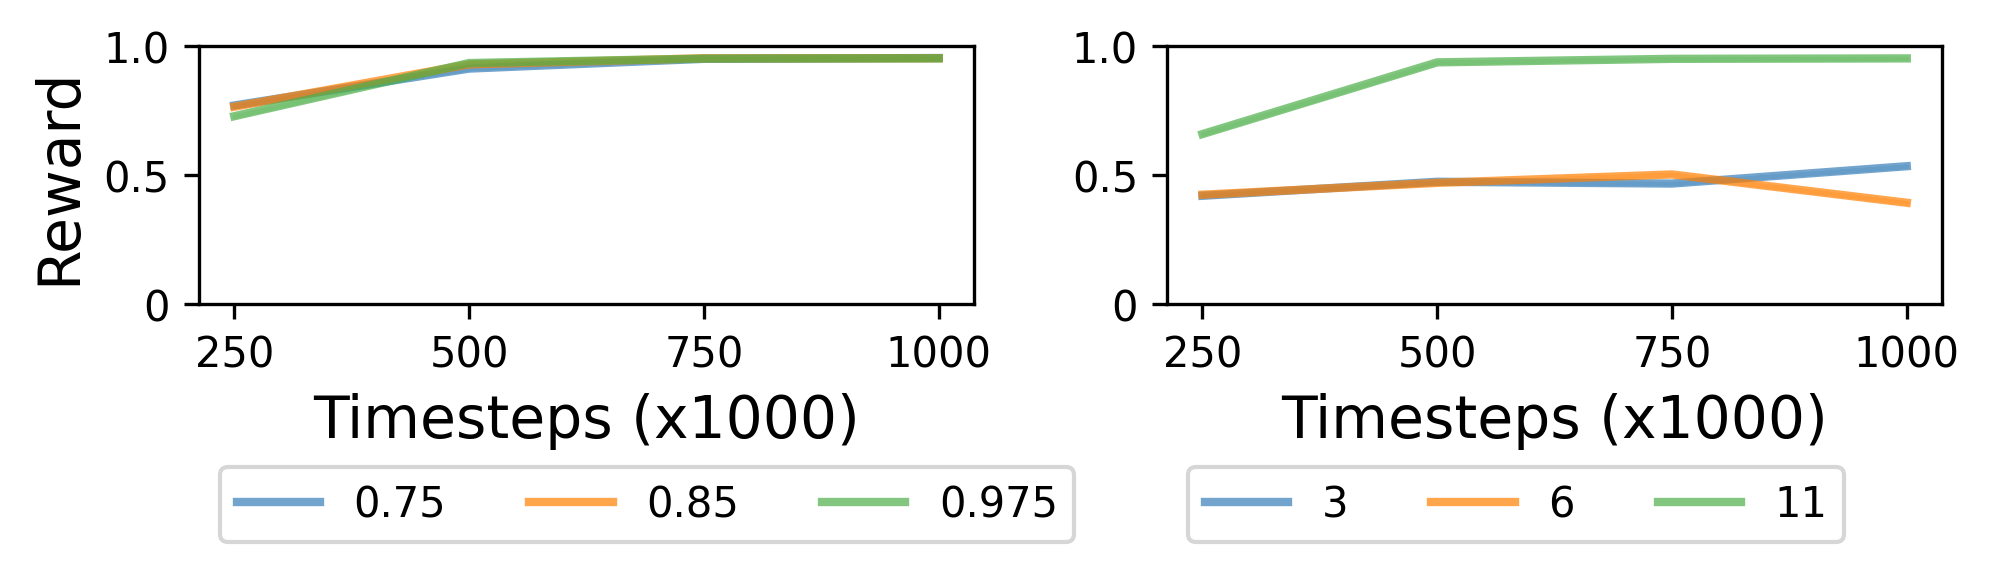

In [28]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,2)
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(2)] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res


sup_y_label = ""
overall_format = {'figsize':(7,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[[0,1,2,3],["250","500","750","1000"]] for i in range(2)]],
    'y_ticks': [[[[0,0.5,1.0],["0","0.5","1.0"]] for i in range(2)]],
    'y_lim': [[[0,1] for i in range(2)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=[["Reward",""]],x_labels=[["Timesteps (x1000)","Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_accuracy
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][0],x_groups,y_vals,y_std,concept_accuracies,line_format)

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_num_concepts 
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][1],x_groups,y_vals,y_std,num_concepts_selected,line_format)


legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0,-1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/accuracy_num_concepts.pdf",dpi=300, bbox_inches='tight')

In [29]:
intervention_probability = [0.25,0.5,0.75]
num_concepts_selected = [3,11,57,48,1]
environments = ["cart_pole","mini_grid","pong","boxing","glucose"]
all_performances = []
for j,e in enumerate(environments):
    performance_env = []
    for i in intervention_probability:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[j], 'intervention_prob': i})
        print(len(matching_params))
        if len(matching_params) > 0:
            performance = [matching_params[0][i]['reward'] for i in ['random','entropy','greedy','lp','multiple']]
        else:
            performance = [0 for i in ['random','entropy','greedy','lp','multiple']]

        performance_env.append(performance)
    all_performances.append(performance_env)

0
0
0
1
1
1
0
0
0
0
0
0
0
0
0


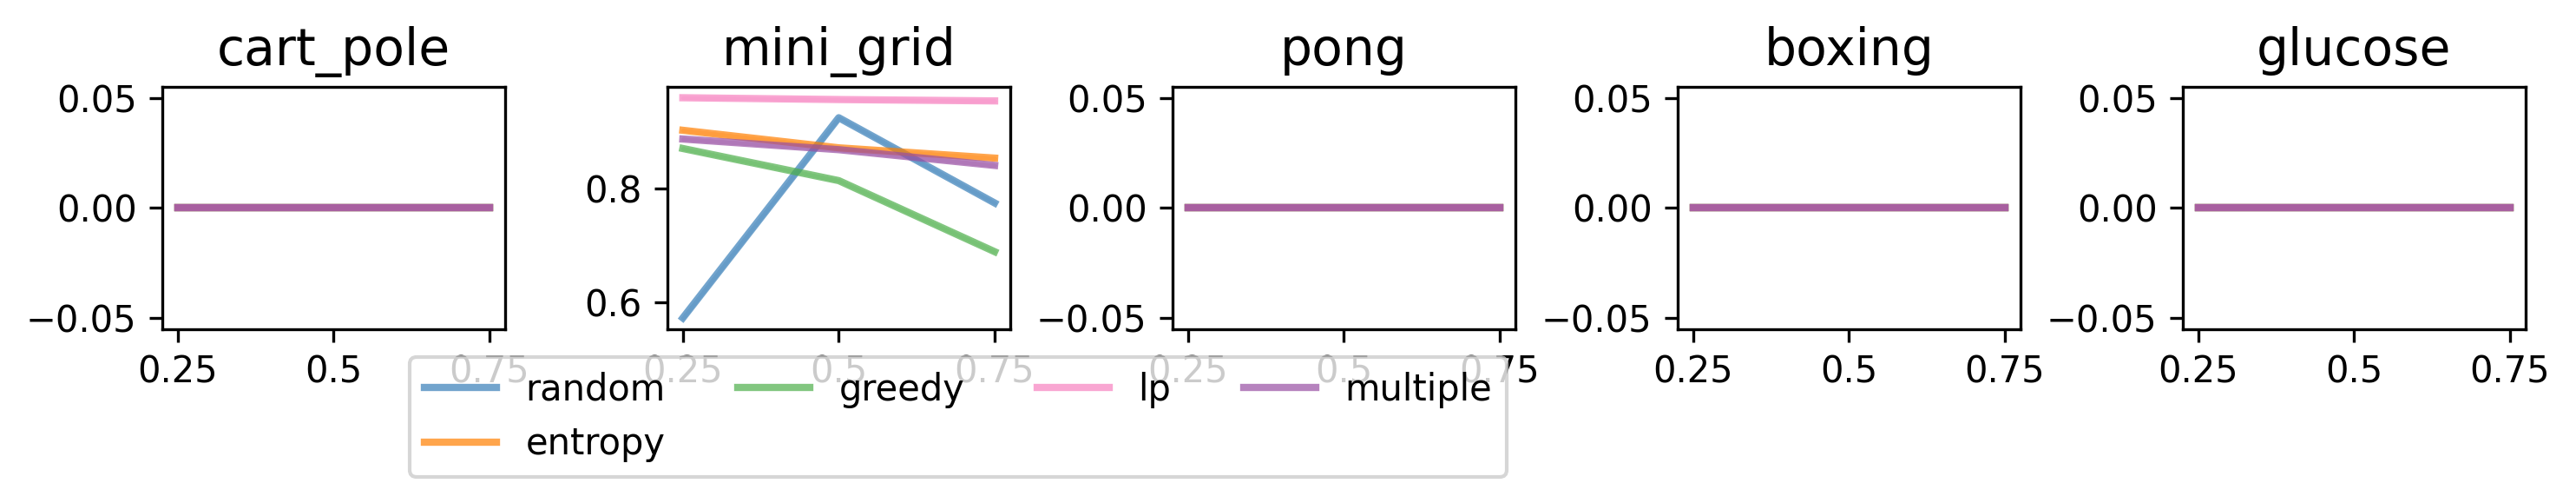

In [30]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,len(environments))
titles = [environments]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),intervention_probability] for i in range(5)] for j in range(1)]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(environments)):
    x_groups = [list(range(len(intervention_probability))) for j in ['random','entropy','greedy','lp','multiple']]
    y_vals = np.array(all_performances[i]).T
    y_std = np.zeros(y_vals.shape)
    plot_line(ax[0][i],x_groups,y_vals,y_std,['random','entropy','greedy','lp','multiple'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')

In [9]:
pareto_curve = get_results_matching_parameters("pareto","",{})
accuracies = pareto_curve[0]['concept_accuracy']
baseline = np.array(pareto_curve[0]['no_intervention'])
intervention = np.array(pareto_curve[0]['intervention'])

In [10]:
old_accuracies = []
new_accuracies = []
intervention_probability = pareto_curve[0]['parameters']['intervention_prob']
all_accuracies = np.array(pareto_curve[0]['concept_accuracy'])

performance_before = [i['reward_baseline'] for i in pareto_curve[0]['lp']['scores']]
performance_after = [i['reward_intervention'] for i in pareto_curve[0]['lp']['scores']]

for i in range(len(pareto_curve[0]['lp']['combos'])):
    old_accuracies.append(np.mean(all_accuracies[pareto_curve[0]['lp']['combos'][i]]))
    new_accuracies.append(np.mean(all_accuracies[pareto_curve[0]['lp']['combos'][i]]*(1-intervention_probability) + np.ones(3)*intervention_probability))
baseline_combo = np.stack([old_accuracies,performance_before]).T
intervention_combo = np.stack([new_accuracies,performance_after]).T

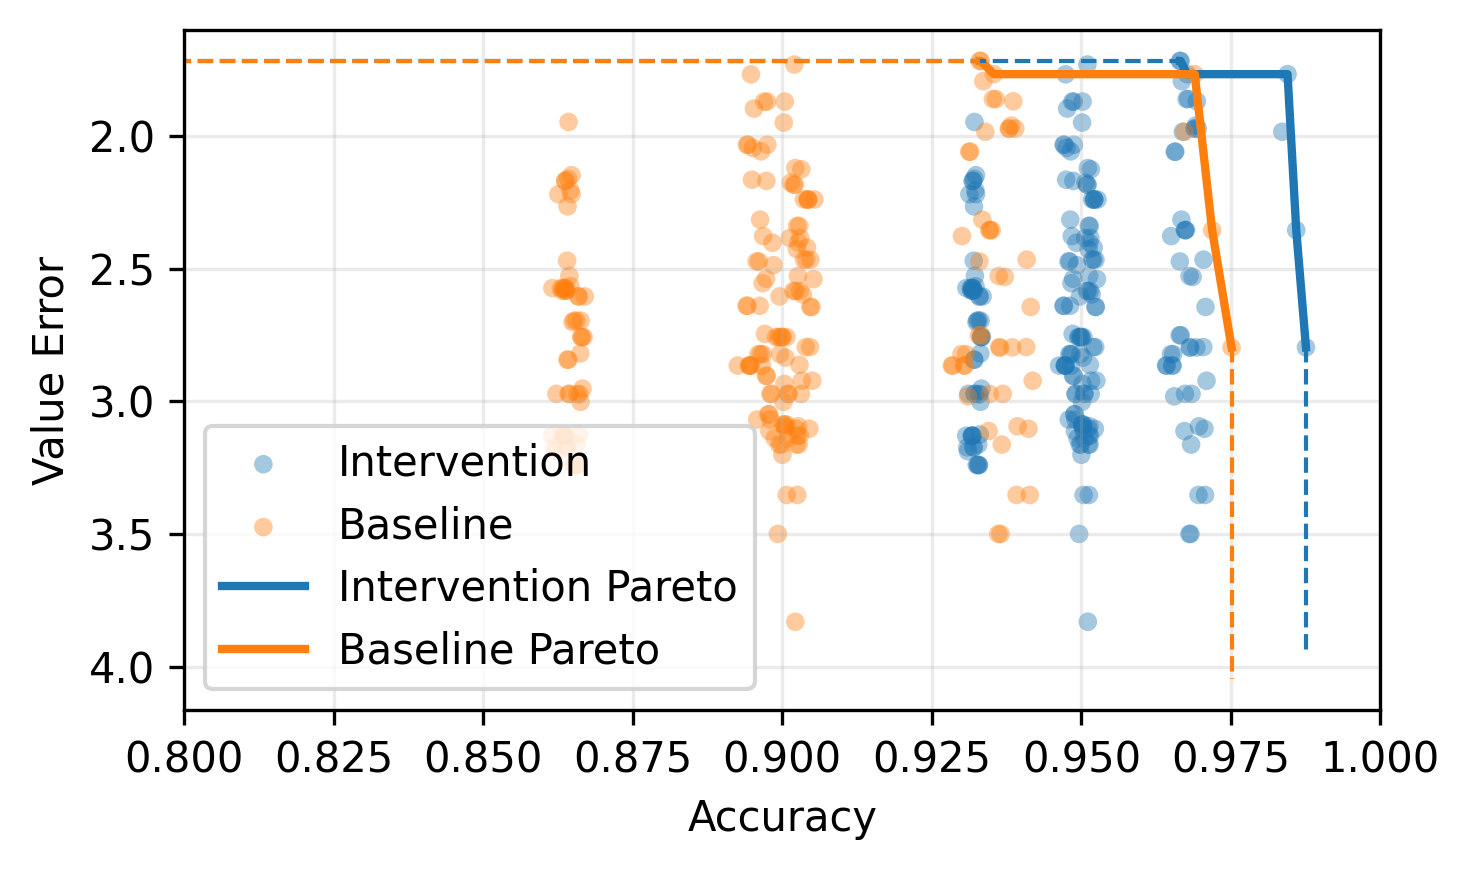

In [11]:
plt.figure(figsize=(5,3))

plt.xlim([0.8,1])
# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
plt.scatter(
    intervention[:,0], intervention[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Intervention'
)
plt.scatter(
    baseline[:,0], baseline[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Baseline'
)

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] <= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention)
baseline_pf     = pareto_front(baseline)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        _, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y0, y_max], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines
extend_to_axes(intervention_pf, color='tab:blue')
extend_to_axes(baseline_pf,      color='tab:orange')

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------
plt.gca().invert_yaxis()

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Accuracy")
plt.ylabel("Value Error")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("../../results/figures/pareto_value_error.pdf",dpi=300, bbox_inches='tight')


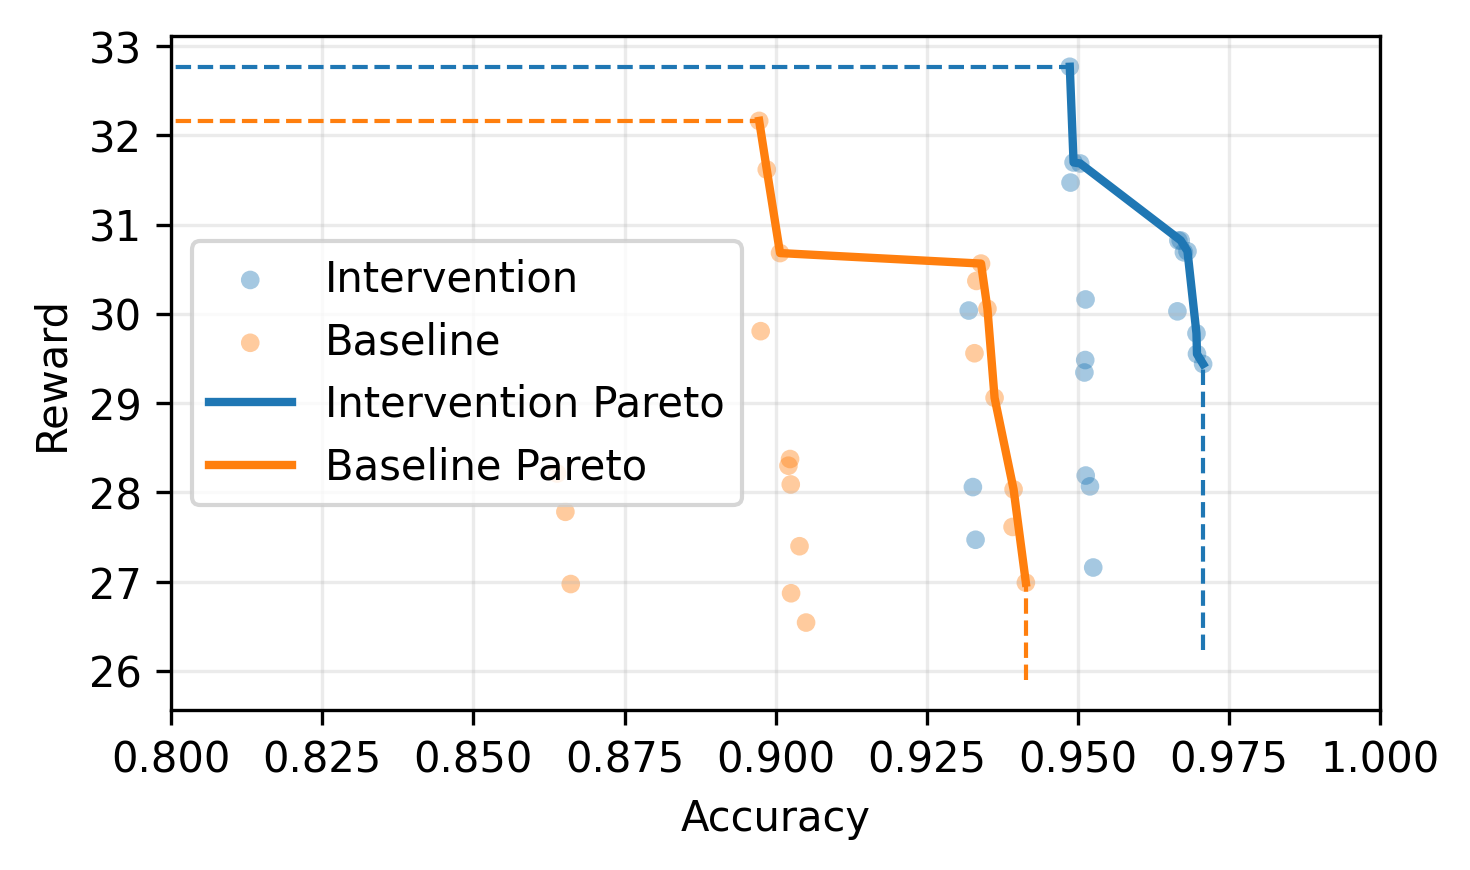

In [105]:
plt.figure(figsize=(5,3))

plt.xlim([0.8,1])
# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
plt.scatter(
    intervention_combo[:,0], intervention_combo[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Intervention'
)
plt.scatter(
    baseline_combo[:,0], baseline_combo[:,1],
    s=20, alpha=0.4, edgecolors='none', label='Baseline'
)

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention_combo)
baseline_pf     = pareto_front(baseline_combo)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        y_min, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y_min,y0], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines
extend_to_axes(intervention_pf, color='tab:blue')
extend_to_axes(baseline_pf,      color='tab:orange')

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Accuracy")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("../../results/figures/pareto_reward.pdf",dpi=300, bbox_inches='tight')



In [32]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311, 'epochs': 50})
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

In [33]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)
iterative_lp = [[m['imperfect']['iterative'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
iterative_lp = np.mean(iterative_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


In [34]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_iterative= [[len(set(m['imperfect']['iterative'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity_iterative = np.mean(similarity_iterative,axis=1)
similarity = np.mean(similarity,axis=1)

In [35]:
imperfect_lp_intervention = [[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
imperfect_lp_intervention = np.mean(imperfect_lp_intervention,axis=0)
multiple_lp_intervention = [[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
multiple_lp_intervention = np.mean(multiple_lp_intervention,axis=0)
iterative_lp_intervention = [[m['intervention']['iterative'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
iterative_lp_intervention = np.mean(iterative_lp_intervention,axis=0)

greedy_intervention = [[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
greedy_intervention = np.mean(greedy_intervention,axis=0)

random_selection_intervention = [[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
random_selection_intervention = np.mean(random_selection_intervention,axis=0)


chosen_concepts_intervention = [[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
chosen_concepts_intervention = np.mean(chosen_concepts_intervention,axis=0)


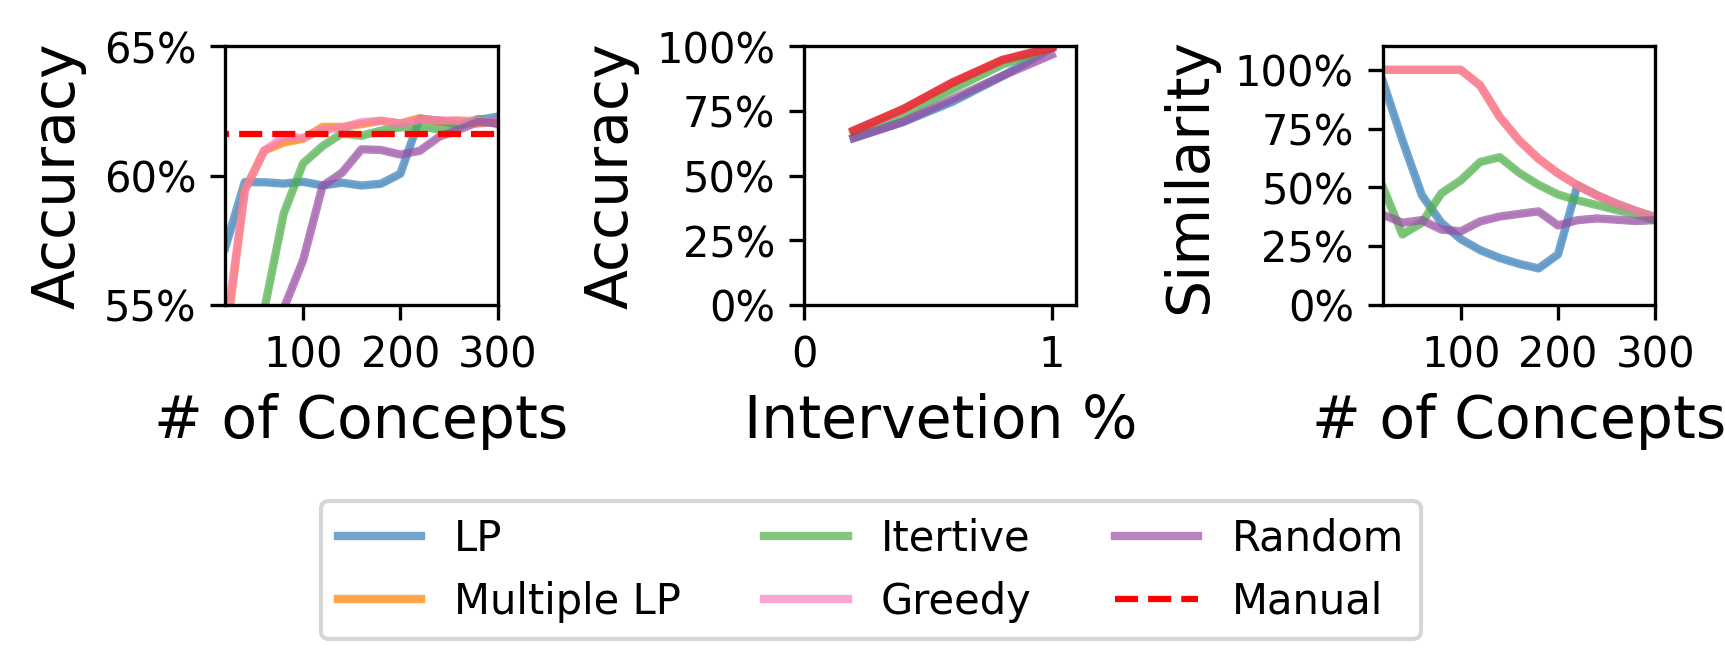

In [36]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)

sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300],[0,1.1],[20,300]]],
    'y_lim': [[[0.55,0.65],[0,1],[0,1.1]]],
    'y_ticks': [[[[0.55,0.6,0.65],["55%","60%","65%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts","Intervetion %","# of Concepts"]],y_labels=[["Accuracy","Accuracy","Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP","Itertive","Greedy","Random"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [imperfect_lp,multiple_lp,iterative_lp,greedy,random_selection]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")
line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["LP","Multiple LP","Itertive","Greedy","Random","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [imperfect_lp_intervention,multiple_lp_intervention,iterative_lp_intervention,greedy_intervention,random_selection_intervention,chosen_concepts_intervention]]

plot_line(ax[0][1],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)


all_labels = ["LP","Multiple LP","Iterative","Greedy","Random"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity,similarity_multiple,similarity_iterative,similarity_greedy,similarity_random]]

plot_line(ax[0][2],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.2,-0.2),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')